<a href="https://www.kaggle.com/code/lalit7881/california-real-estate-snapshot-2026?scriptVersionId=307841713" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/california-real-estate-market-2026/california_sold_properties_2026_final.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/california-real-estate-market-2026/california_sold_properties_2026_final.csv")

In [3]:
df.head()

,type,sub_type,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,sanitized_property_summary
0,single_family,NaN,599000.0,1083.0,1.0,3.0,2.0,2.0,2.0,1.0,1925.0,3BD/2BA single-family detached home in a neigh...
1,single_family,NaN,479000.0,1927.0,1.0,3.0,2.0,2.0,2.0,2.0,1976.0,Nestled in the highly sought-after neighborhoo...
2,single_family,NaN,748000.0,1203.0,1.0,2.0,2.0,2.0,2.0,2.0,1974.0,Perched on a greenbelt within the highly desir...
3,multi_family,NaN,599000.0,1038.0,NaN,2.0,NaN,NaN,NaN,NaN,1925.0,3BD/2BA can be used as a single-family detache...
4,single_family,NaN,1099000.0,3261.0,1.0,4.0,5.0,4.0,4.0,2.0,2004.0,This customized model is nestled in a lushly l...


In [4]:
df.tail()

,type,sub_type,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,sanitized_property_summary
9576,land,NaN,340000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Property features standard residential ameniti...
9577,single_family,NaN,1275000.0,910.0,1.0,2.0,1.0,1.0,1.0,1.0,1942.0,"Charming 2-bedroom, 1-bath home offers 910 squ..."
9578,land,NaN,849000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nearly 2.25 acres of flat land lie in front of...
9579,single_family,NaN,750000.0,3179.0,2.0,4.0,3.0,3.0,3.0,2.0,2004.0,"4-bedroom, offers no HOA, low taxes, stunning ..."
9580,condos,condo,319900.0,872.0,1.0,2.0,2.0,2.0,2.0,1.0,1987.0,"2 bedroom, 2 bathroom condominium located in t..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9581 entries, 0 to 9580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   type                        9581 non-null   object 
 1   sub_type                    1648 non-null   object 
 2   listPrice                   9393 non-null   float64
 3   sqft                        8908 non-null   float64
 4   stories                     8367 non-null   float64
 5   beds                        8959 non-null   float64
 6   baths                       9005 non-null   float64
 7   baths_full                  8878 non-null   float64
 8   baths_full_calc             8930 non-null   float64
 9   garage                      6778 non-null   float64
 10  year_built                  8963 non-null   float64
 11  sanitized_property_summary  9581 non-null   object 
dtypes: float64(9), object(3)
memory usage: 898.3+ KB


In [6]:
df.describe()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
count,9.393000e+03,8908.000000,8367.000000,8959.000000,9005.000000,8878.000000,8930.000000,6778.000000,8963.000000
mean,1.041601e+06,1891.538392,1.454404,3.216877,2.503165,2.191485,2.247480,2.321629,1979.020194
std,1.315264e+06,1602.389834,0.614818,1.363889,1.382490,0.993075,0.979409,13.699686,27.219465
min,1.000000e+03,100.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1801.000000
25%,4.700000e+05,1251.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,1960.000000
50%,7.249980e+05,1651.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,1980.000000
75%,1.200000e+06,2223.000000,2.000000,4.000000,3.000000,3.000000,3.000000,2.000000,2000.000000
max,3.500000e+07,112184.000000,6.000000,48.000000,61.000000,23.000000,23.000000,999.000000,2026.000000


In [7]:
df.dtypes

type                           object
sub_type                       object
listPrice                     float64
sqft                          float64
stories                       float64
beds                          float64
baths                         float64
baths_full                    float64
baths_full_calc               float64
garage                        float64
year_built                    float64
sanitized_property_summary     object
dtype: object

In [8]:
df.shape

(9581, 12)

In [9]:
df.columns

Index(['type', 'sub_type', 'listPrice', 'sqft', 'stories', 'beds', 'baths',
       'baths_full', 'baths_full_calc', 'garage', 'year_built',
       'sanitized_property_summary'],
      dtype='object')

In [10]:
df.isnull().sum()

type                             0
sub_type                      7933
listPrice                      188
sqft                           673
stories                       1214
beds                           622
baths                          576
baths_full                     703
baths_full_calc                651
garage                        2803
year_built                     618
sanitized_property_summary       0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(44)

In [12]:
df.nunique()

type                            11
sub_type                         2
listPrice                     2306
sqft                          2841
stories                          7
beds                            21
baths                           22
baths_full                      17
baths_full_calc                 17
garage                          19
year_built                     138
sanitized_property_summary    9134
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(44)

## EDA

            type sub_type  listPrice    sqft  stories  beds  baths  \
0  single_family      NaN   599000.0  1083.0      1.0   3.0    2.0   
1  single_family      NaN   479000.0  1927.0      1.0   3.0    2.0   
2  single_family      NaN   748000.0  1203.0      1.0   2.0    2.0   
3   multi_family      NaN   599000.0  1038.0      NaN   2.0    NaN   
4  single_family      NaN  1099000.0  3261.0      1.0   4.0    5.0   

   baths_full  baths_full_calc  garage  year_built  \
0         2.0              2.0     1.0      1925.0   
1         2.0              2.0     2.0      1976.0   
2         2.0              2.0     2.0      1974.0   
3         NaN              NaN     NaN      1925.0   
4         4.0              4.0     2.0      2004.0   

                          sanitized_property_summary  
0  3BD/2BA single-family detached home in a neigh...  
1  Nestled in the highly sought-after neighborhoo...  
2  Perched on a greenbelt within the highly desir...  
3  3BD/2BA can be used as a single

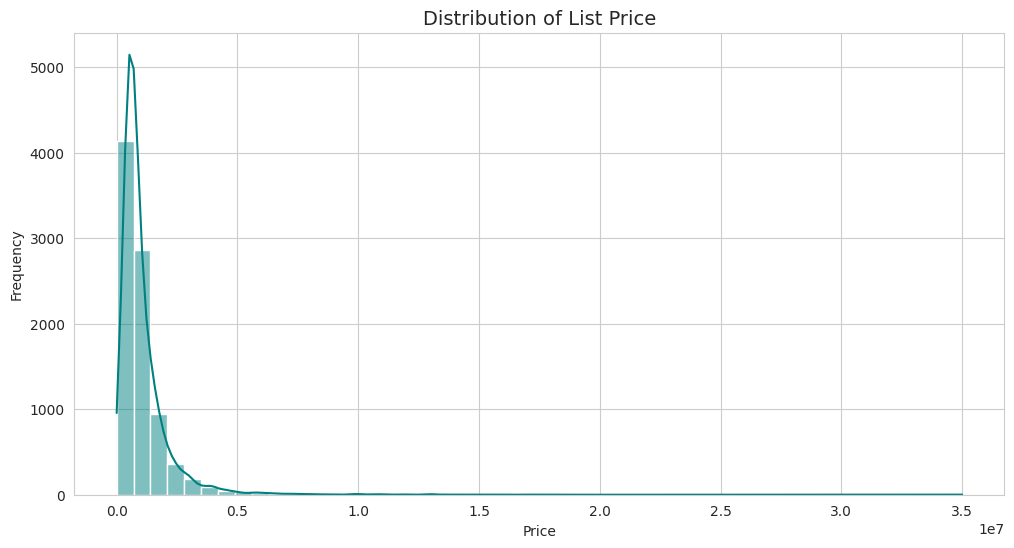

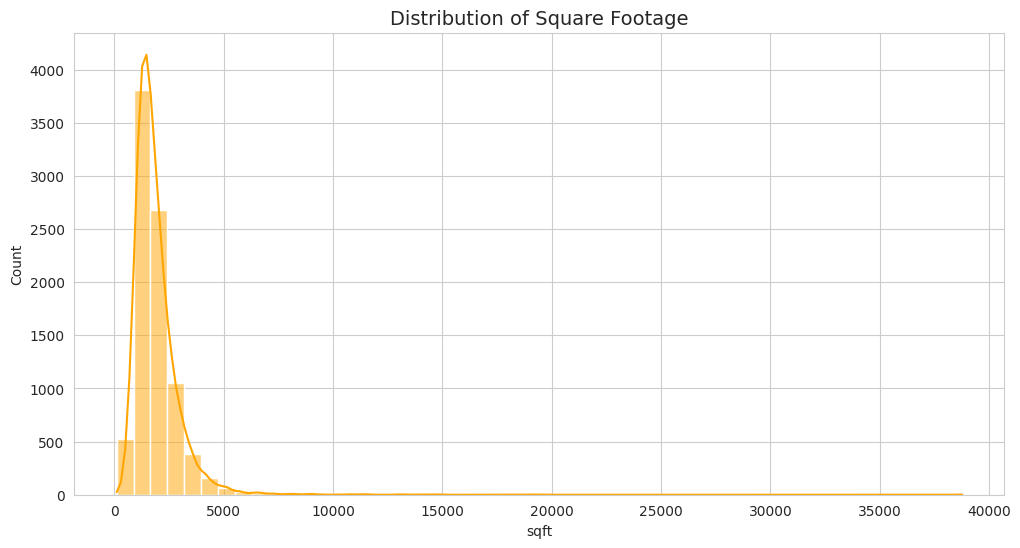

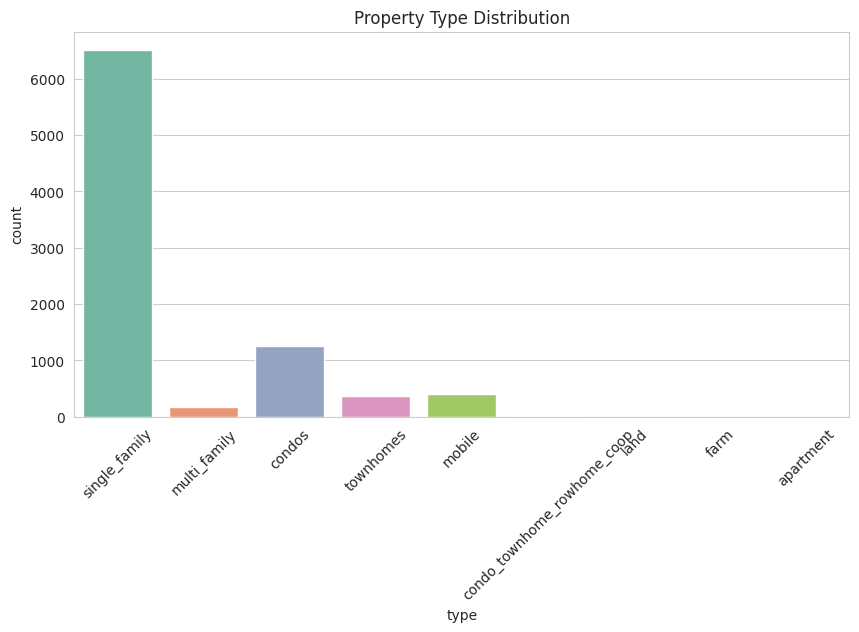

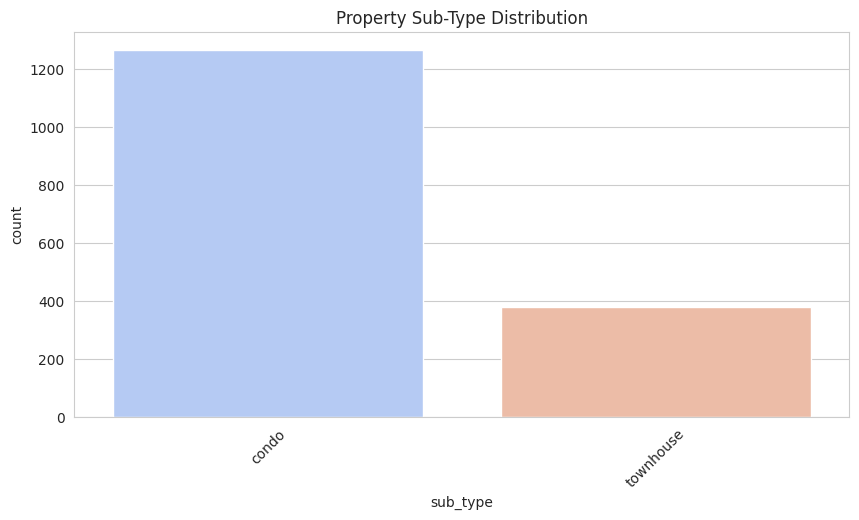

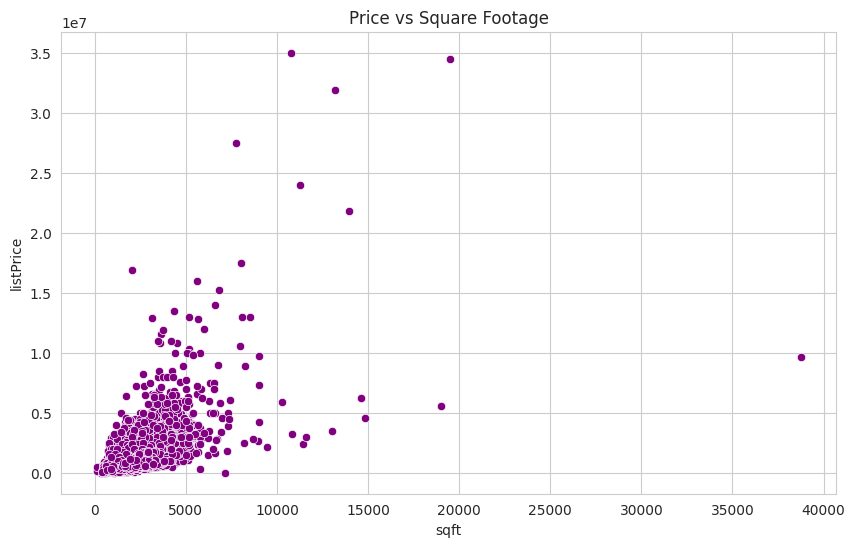

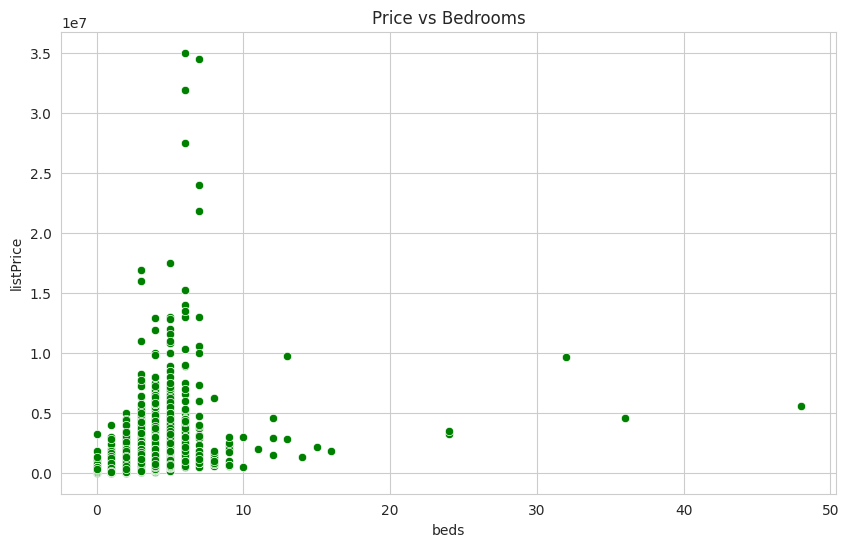

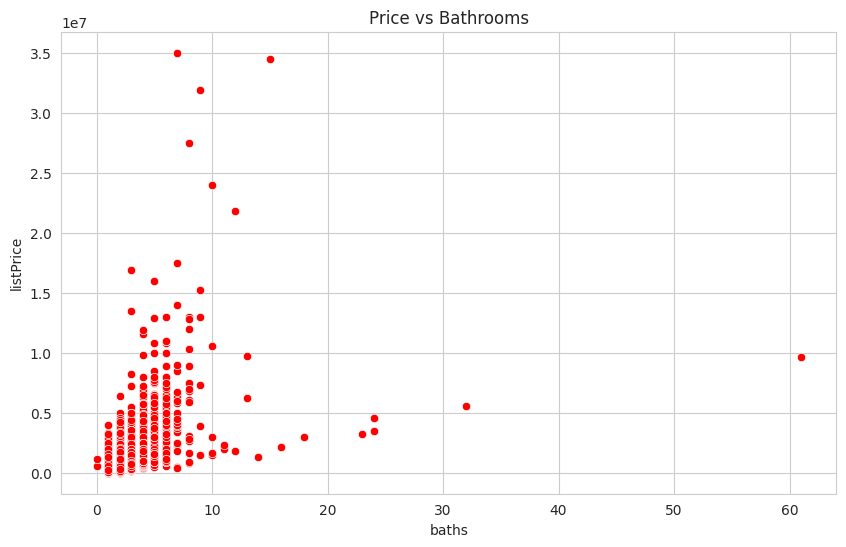

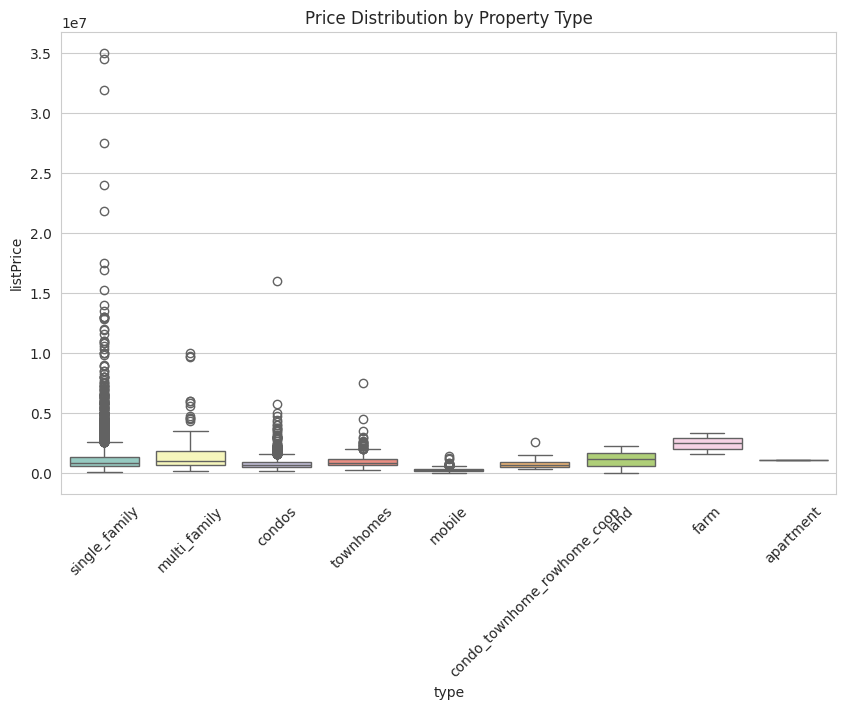

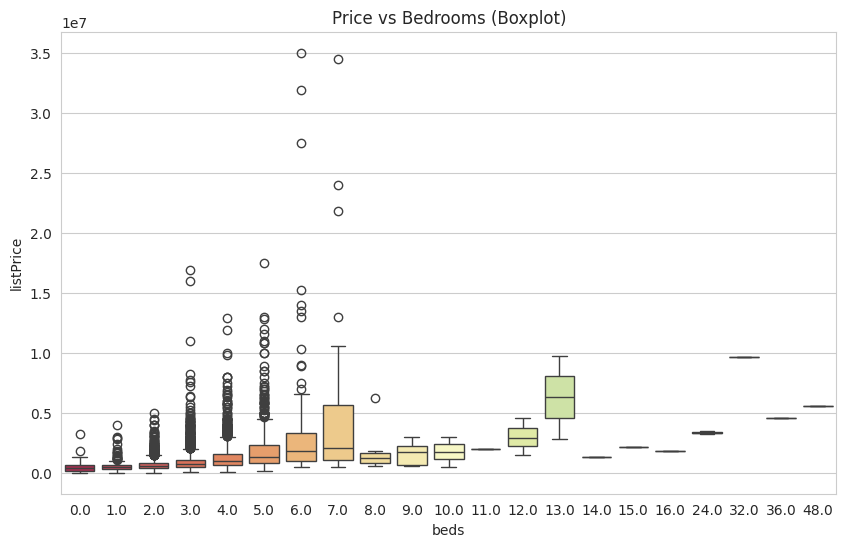

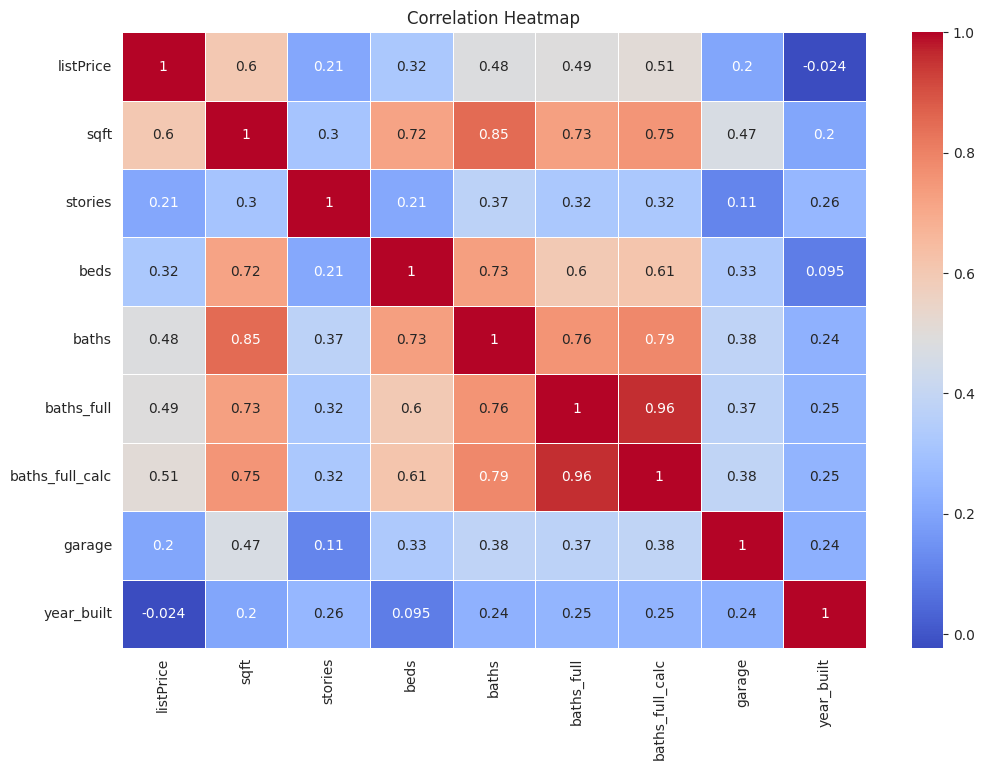

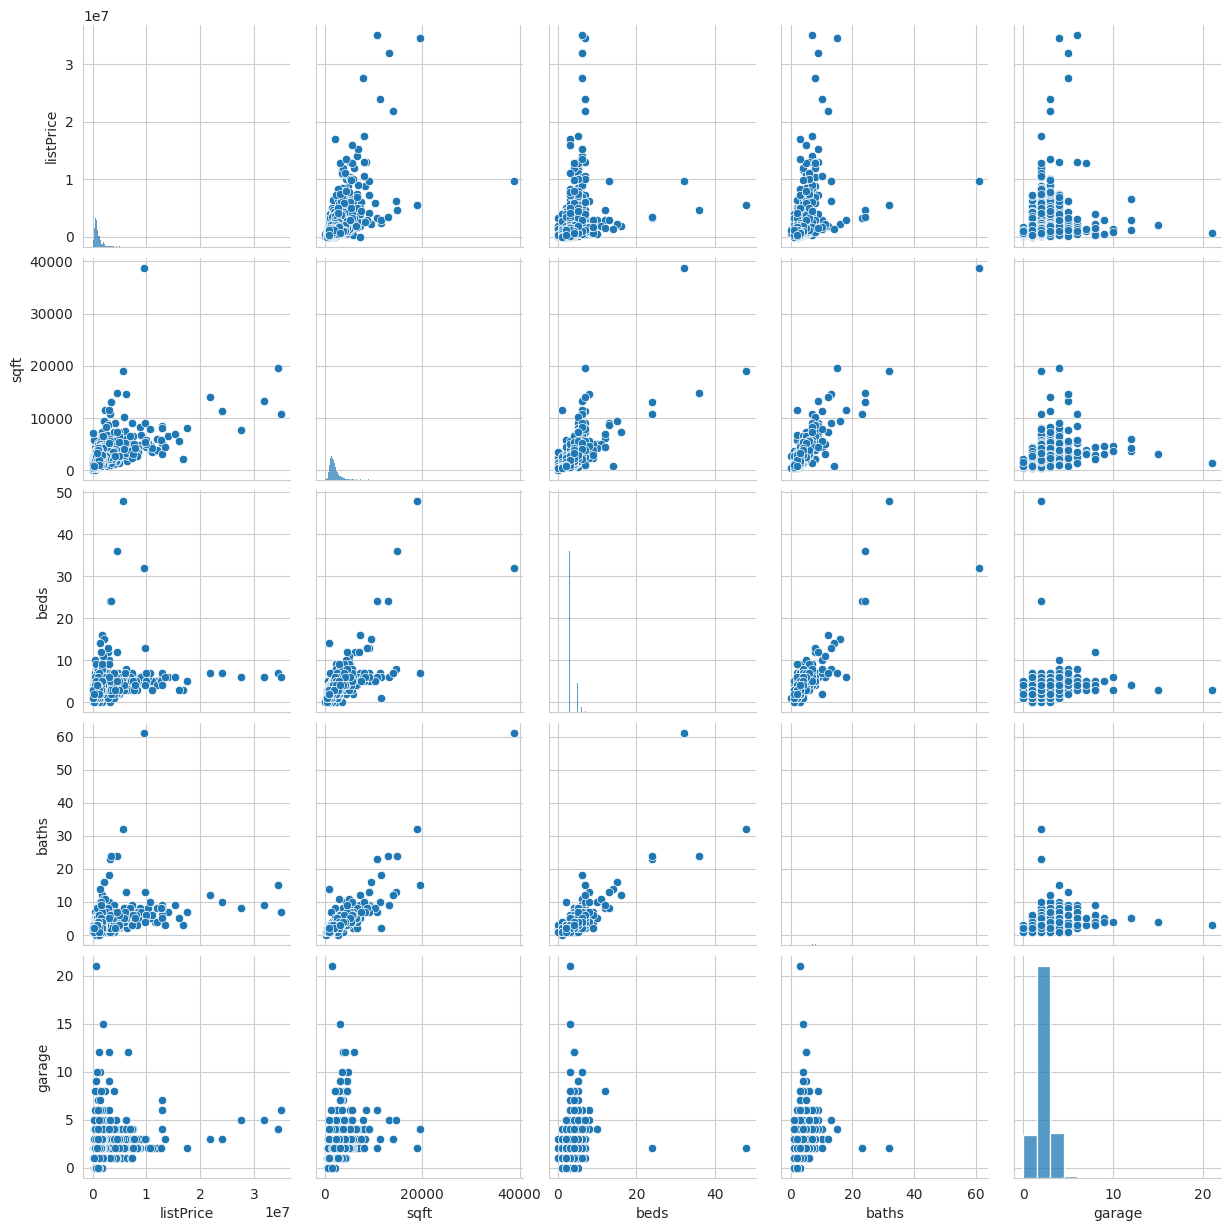

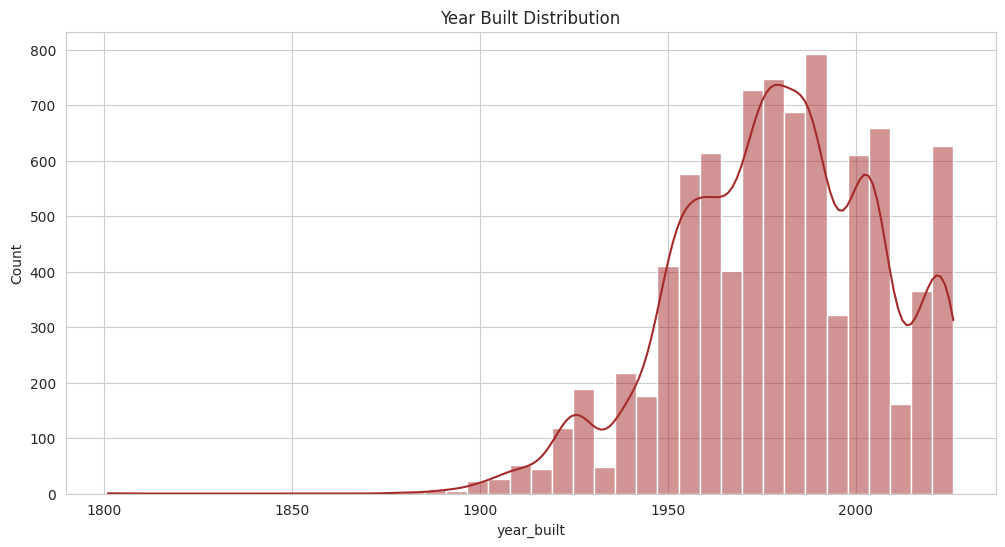

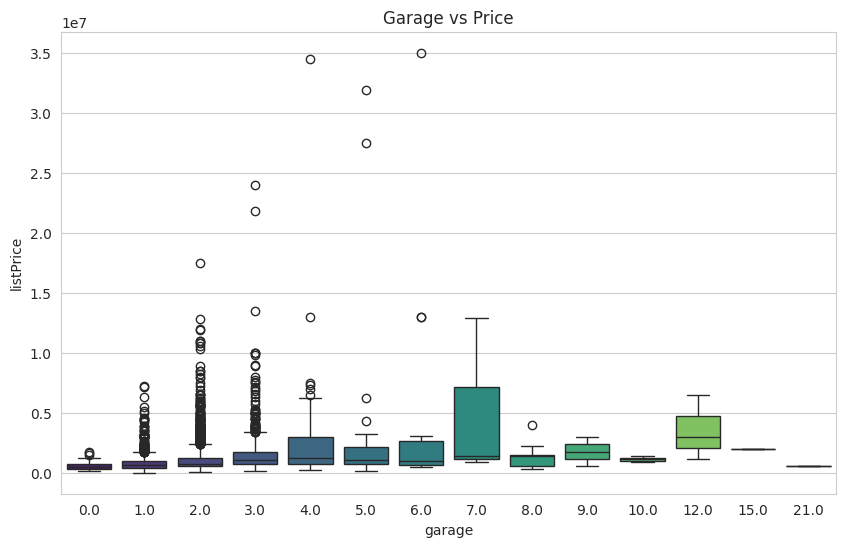

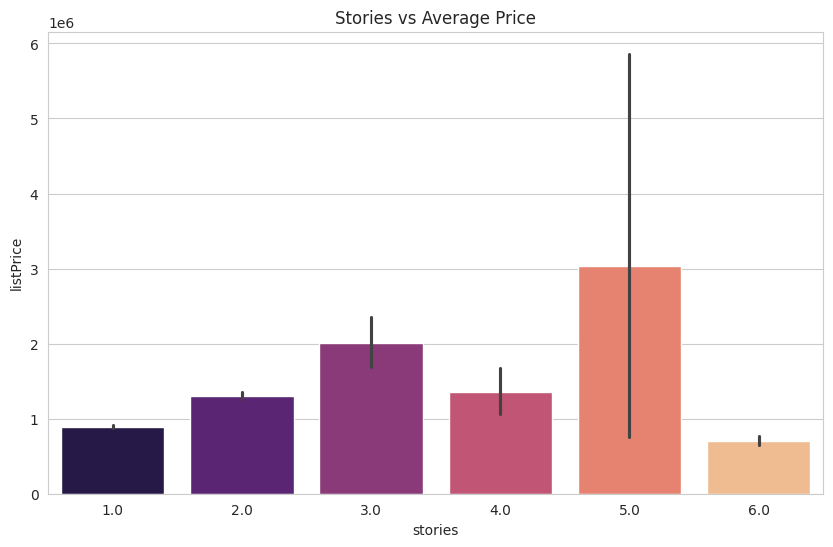

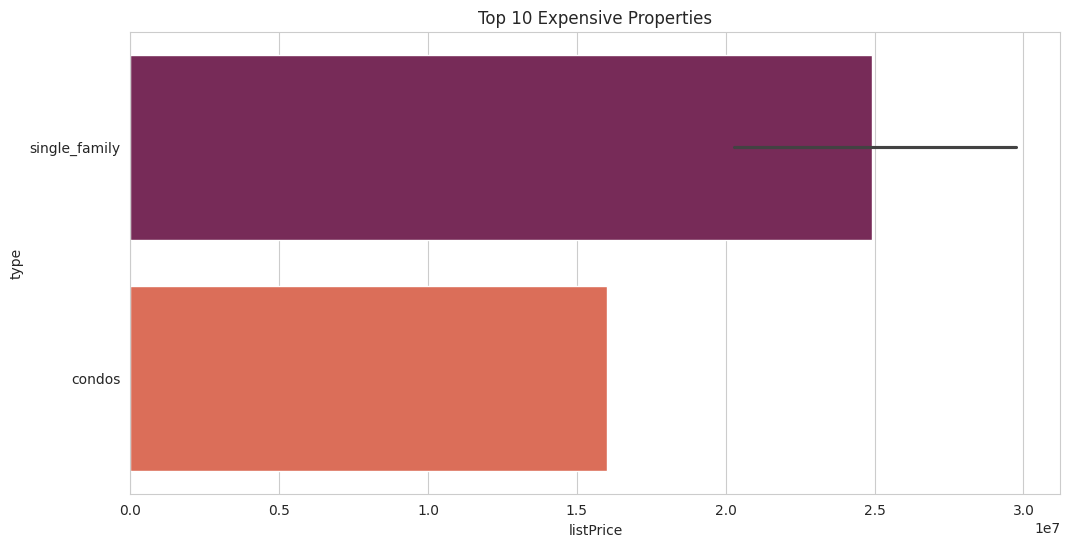

In [14]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")


# Preview
print(df.head())
print(df.info())

# ==============================
# 3. Basic Cleaning
# ==============================
# Convert numeric columns safely
num_cols = ['listPrice', 'sqft', 'stories', 'beds', 'baths',
            'baths_full', 'baths_full_calc', 'garage', 'year_built']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing values for simplicity
df = df.dropna(subset=['listPrice', 'sqft'])

# ==============================
# 4. Distribution Plots
# ==============================
plt.figure(figsize=(12,6))
sns.histplot(df['listPrice'], bins=50, color='teal', kde=True)
plt.title("Distribution of List Price", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(df['sqft'], bins=50, color='orange', kde=True)
plt.title("Distribution of Square Footage", fontsize=14)
plt.show()

# ==============================
# 5. Count Plots (Categorical)
# ==============================
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='type', palette='Set2')
plt.title("Property Type Distribution")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='sub_type', palette='coolwarm')
plt.title("Property Sub-Type Distribution")
plt.xticks(rotation=45)
plt.show()

# ==============================
# 6. Price vs Features
# ==============================
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='sqft', y='listPrice', color='purple')
plt.title("Price vs Square Footage")
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='beds', y='listPrice', color='green')
plt.title("Price vs Bedrooms")
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='baths', y='listPrice', color='red')
plt.title("Price vs Bathrooms")
plt.show()

# ==============================
# 7. Box Plots (Outlier Analysis)
# ==============================
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='type', y='listPrice', palette='Set3')
plt.title("Price Distribution by Property Type")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='beds', y='listPrice', palette='Spectral')
plt.title("Price vs Bedrooms (Boxplot)")
plt.show()

# ==============================
# 8. Correlation Heatmap
# ==============================
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# ==============================
# 9. Pair Plot (Important)
# ==============================
sns.pairplot(
    df[['listPrice', 'sqft', 'beds', 'baths', 'garage']],
    palette='husl'
)
plt.show()

# ==============================
# 10. Year Built Analysis
# ==============================
plt.figure(figsize=(12,6))
sns.histplot(df['year_built'], bins=40, color='brown', kde=True)
plt.title("Year Built Distribution")
plt.show()

# ==============================
# 11. Garage Impact
# ==============================
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='garage', y='listPrice', palette='viridis')
plt.title("Garage vs Price")
plt.show()

# ==============================
# 12. Stories vs Price
# ==============================
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='stories', y='listPrice', palette='magma')
plt.title("Stories vs Average Price")
plt.show()

# ==============================
# 13. Top Expensive Properties
# ==============================
top = df.sort_values(by='listPrice', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top['listPrice'],
    y=top['type'],
    palette='rocket'
)
plt.title("Top 10 Expensive Properties")
plt.show()

## Feature engineering


Logistic Regression
Accuracy : 0.7368
ROC-AUC  : 0.8164
----------------------------------------

Random Forest
Accuracy : 0.742
ROC-AUC  : 0.8215
----------------------------------------

Gradient Boosting
Accuracy : 0.7546
ROC-AUC  : 0.8388
----------------------------------------


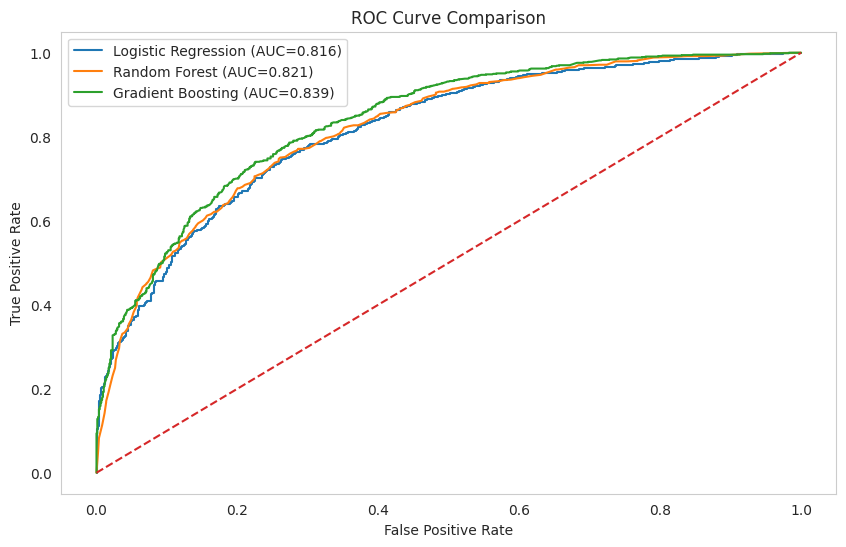


Best Model: Gradient Boosting


In [15]:
# ======================================
# 1. Import Libraries
# ======================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer   # ⭐ IMPORTANT

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# ======================================
# 2. Columns
# ======================================
num_cols = ['sqft', 'stories', 'beds', 'baths',
            'baths_full', 'baths_full_calc', 'garage', 'year_built']

cat_cols = ['type', 'sub_type']

# ======================================
# 3. Cleaning
# ======================================
for col in num_cols + ['listPrice']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['listPrice'])

# ======================================
# 4. Target
# ======================================
median_price = df['listPrice'].median()
df['target'] = (df['listPrice'] > median_price).astype(int)

# ======================================
# 5. Split
# ======================================
X = df.drop(['target', 'listPrice', 'sanitized_property_summary'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================
# 6. Preprocessing (FIXED PIPELINE)
# ======================================

# ⭐ Numeric pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # FIX
    ('scaler', StandardScaler())
])

# ⭐ Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # FIX
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# ======================================
# 7. Models
# ======================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

# ======================================
# 8. Training + Evaluation
# ======================================
results = {}

plt.figure(figsize=(10,6))

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = (acc, roc_auc)

    print(f"\n{name}")
    print("Accuracy :", round(acc, 4))
    print("ROC-AUC  :", round(roc_auc, 4))
    print("-"*40)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

# ======================================
# 9. ROC Plot
# ======================================
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

# ======================================
# 10. Best Model
# ======================================
best_model = max(results, key=lambda x: results[x][1])
print("\nBest Model:", best_model)

## Thank you..pls upvote!!!!!!!!!